In [52]:
"""
Code for cuquantum simulation 
of neutrino interactions.
"""

'\nCode for cuquantum simulation \nof neutrino interactions.\n'

In [53]:
import qiskit as qk

# to remove the +computecanada postfix in version number, which cause error
import importlib.metadata

# Save original version
_real_version = importlib.metadata.version

# Define patch
def patched_version(pkg_name):
    if pkg_name == "qiskit":
        return _real_version(pkg_name).split("+")[0]
    return _real_version(pkg_name)

# Apply patch
importlib.metadata.version = patched_version

import numpy as np
from matplotlib import pyplot as plt

import warnings
# warnings.filterwarnings("ignore")

# Suppress the warning from importing cuquantum
# from cuquantum import cutensornet as tn

# warnings.resetwarnings()

In [54]:
"""
Set up to evaluate classical solution for nunubar
"""
import numpy as np

L          = 0.5
t_steps    = 5
theta      = np.pi/2 - 0.2
dmsq       = 1.0
initial_state = ['e'] * 2 + ['mu'] * 2
n_qubits   = len(initial_state)
Delta      = dmsq / (2*0.1) * np.array([1.] * n_qubits)
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((n_qubits, n_qubits))

In [55]:
from tqdm import tqdm

In [56]:
import sys
sys.path.append('../joachim')

In [57]:
from mft import P_osc_RS
from mft import sigma_0, sigma_1, sigma_2, sigma_3

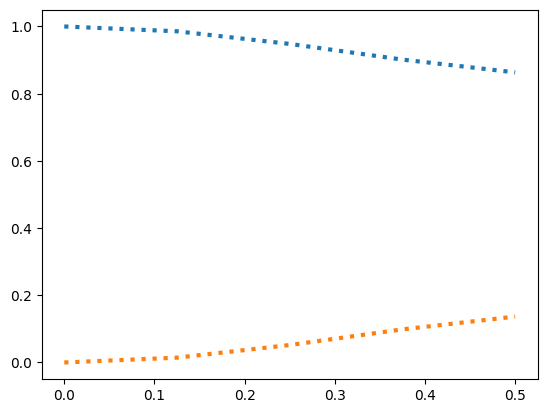

In [58]:
# mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, Delta, 0., abs(J), initial_flavors=initial_state) # factor 2 because we compare to a system with 2 nu + 2 nubar
MFT_P_table = np.reshape(sol.y, (n_qubits,3,len(L_table)))

# P_table = np.reshape(sol.y, (4,3,len(L_table)))

plt.plot(L_table, 0.5*(1+MFT_P_table[0,2,:]), ls=':', lw=3)
plt.plot(L_table, 0.5*(1+MFT_P_table[-1,2,:]), ls=':', lw=3)

In [59]:
adaptive_l_table = L_table

In [60]:
from scipy.linalg import expm

def U_nunu(theta):
    """the exponential of the neutrino-neutrino interaction Hamiltonian,
       exp(-1j*H_self_int(theta))), see Friedland & Lunardini,
       https://arxiv.org/abs/hep-ph/0304055
    """
    return np.array([[np.exp(-1j*theta), 0,                          0,                          0],
                     [0,                 0.5*( 1+np.exp(-1j*theta)), 0.5*(-1+np.exp(-1j*theta)), 0],
                     [0,                 0.5*(-1+np.exp(-1j*theta)), 0.5*( 1+np.exp(-1j*theta)), 0],
                     [0,                 0,                          0,                          np.exp(-1j*theta)]])

In [ ]:
def initialize_from_rdm(qc, rdms):
    """
    We want to initialize an empty circuit (all |0>) to the state given by the reduced density matrices (rdms).
    """
    for k in range(len(rdms)):
        p = np.real(np.array([np.trace(sigma_1 @ rdms[k]), 
                          np.trace(sigma_2 @ rdms[k]), 
                          np.trace(sigma_3 @ rdms[k])]))
        qc.ry(np.arccos(p[2]), k)
        qc.rz(np.arctan2(p[1], p[0]), k)

def build_one_step_circuit(dt, rdms=None):
    """
    Builds the evolution circuit for a single time step of dt.
    """
    # If reduced density matrices are given, initialize the circuit from them
    qc = qk.QuantumCircuit(n_qubits)
    if rdms is not None:
        initialize_from_rdm(qc, rdms)

    # Apply the vacuum interaction term
    for j in range(n_qubits):
        qc.rx(-dt*Delta[j]*b[0], j)
        qc.rz(-dt*Delta[j]*b[2], j)

    # Apply the self-interaction term
    for iq1 in range(n_qubits):
        for iq2 in range(iq1+1, n_qubits):
                qc.unitary(U_nunu(-dt*J[iq1, iq2]), [iq1, iq2])
                
    return qc

def evaluate_rdm(qc):
    converter = tn.CircuitToEinsum(qc)
    qubits = qc.qubits

    rdms = []

    # evaluate the reduced density matrices one by one
    for i in range(len(qubits)):
        where = (qubits[i],)
        fixed = {} # generate unbiased
        expr, operd = converter.reduced_density_matrix(where, fixed = fixed)

        # use simple contraction for now
        tmp_rdm = tn.contract(expr, *operd)

        tmp_rdm = tmp_rdm.get()

        # reshape and convert to numpy array
        tmp_rdm = tmp_rdm.reshape(2, 2)
        tmp_rdm = np.array(tmp_rdm)

        # normalize
        tmp_rdm /= np.trace(tmp_rdm)

        rdms.append(tmp_rdm)

    return rdms

def get_initial_rdms():
    rdms = []

    for flvr in initial_state:
        if flvr == 'e':
            rdms.append(np.array([[1, 0], [0, 0]]))  # |nu_e><nu_e|
        else:
            rdms.append(np.array([[0, 0], [0, 1]])) # |nu_mu><nu_mu|

    return rdms


In [62]:
dt_table = np.diff(adaptive_l_table, prepend=0)

rdm_step_dict = {}

rdm_step_dict[0] = get_initial_rdms()

print("Calculation start ...")

for i, dt in tqdm(enumerate(dt_table)):

    if i == 0:
        continue

    qc = build_one_step_circuit(dt, rdms=rdm_step_dict[i-1])
    rdms = evaluate_rdm(qc)
    rdm_step_dict[i] = rdms

print("All reduced density matrices calculated.")

Calculation start ...


1it [00:00, 133.33it/s]


NameError: name 'tn' is not defined

In [ ]:
# Convert everything to probabilities and plot

print("Converting to probabilities ...")

prob = np.zeros((n_qubits, len(dt_table)))

for it in range(len(dt_table)):
    for k in range(n_qubits):
        prob[k, it] = np.abs(rdm_step_dict[it][k][0, 0])

print("Finished converting to probabilities.")


In [ ]:
plt.clf()

plt.plot(L_table, 0.5*(1+MFT_P_table[0,2,:]), ls=':', lw=3)
plt.plot(L_table, 0.5*(1+MFT_P_table[-1,2,:]), ls=':', lw=3)

plt.plot(adaptive_l_table, prob[0, :], color='orange')
plt.plot(adaptive_l_table, prob[-1, :], color='blue')

plt.xlabel("L")
plt.ylabel(r"$P_{\nu_e}$")

plt.savefig("test.png")